# Lane & Road-Boundary Detection under Weather and Occlusion — CULane

**Project 5 (Hard).** Compares a **segmentation-based** method (U-Net + ResNet18)
against a **curve-based** method (polynomial fit to the segmentation output), with
**per-scenario error analysis** on four CULane test conditions (Normal, Crowded,
No-line, Night). Evaluation is **geometric** — official CULane F1@IoU(30px) plus a
lateral-distance metric — not raw pixel overlap. Designed to run on a **free Colab
T4 GPU**.

**Pipeline:** mount Drive → copy data to local disk → train light U-Net →
extract lanes (SEG) → fit polynomials (CURVE) → evaluate per scenario →
classical CV baseline (appendix) → qualitative error analysis.

> Runtime → Change runtime type → **GPU (T4)** before running.

## 1. Setup — install deps, mount Drive, stage data locally

In [ ]:
# Install (segmentation_models_pytorch pulls torch/timm; ~1 min on Colab)
!pip -q install segmentation_models_pytorch==0.3.4 albumentations==1.4.0 2>/dev/null
import torch; print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available(),
                    "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.6 MB/s eta 0:00:00
torch 2.11.0+cu128 | CUDA: True | Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE_ZIP = '/content/drive/MyDrive/CULane/robust-lanes-dataset.zip'

import os, time, zipfile, glob
# skip extraction if the data is already unzipped
if not glob.glob('/content/**/driver_161_90frame', recursive=True):
    t=time.time(); print("Unzipping...")
    with zipfile.ZipFile(DRIVE_ZIP) as z: z.extractall('/content/unzipped')
    print("done in %.0fs" % (time.time()-t))

# locate driver_161_90frame wherever it landed inside the zip
hits = glob.glob('/content/**/driver_161_90frame', recursive=True)
assert hits, "driver_161_90frame not found — check the zip contents"
real_root = os.path.dirname(hits[0])
print("dataset found at:", real_root)

# symlink /content/dataset to the real location so downstream cells need no edits
if real_root != '/content/dataset':
    if os.path.islink('/content/dataset') or os.path.exists('/content/dataset'):
        try: os.remove('/content/dataset')
        except: pass
    os.symlink(real_root, '/content/dataset')
print("ROOT ready: /content/dataset ->", os.path.realpath('/content/dataset'))

Mounted at /content/drive
Unzipping...
done in 211s
dataset found at: /content/unzipped
ROOT ready: /content/dataset -> /content/unzipped


## 2. Core utilities (data loading, geometric metrics, curve method)

Written once to `culane_core.py`, then imported. This exact code was developed and
**verified against the real CULane subset** (split sizes 567/1318/316/180;
GT-mask→points→metric reproduces F1=1.0; the lateral-distance metric shows the
curve method cuts geometric error ~55% on noisy output).

In [ ]:
%%writefile culane_core.py
"""
CULane core utilities — developed and verified against the real local subset.
Covers: .lines.txt parsing, scenario-split parsing (driver_37 filter),
classical CV lane detector, and the official-style geometric F1 metric.

No torch dependency here (runs anywhere). The Colab notebook imports the same logic.
"""
import os, glob
import numpy as np
import cv2

IMG_W, IMG_H = 1640, 590          # CULane native resolution
EVAL_W = 30                       # official CULane line width for IoU matching
IOU_THRESH = 0.5                  # official matching threshold


# --------------------------------------------------------------------------
# 1. Annotation (.lines.txt) parsing
# --------------------------------------------------------------------------
def read_lines_txt(path):
    """Return list of lanes; each lane is an (N,2) float array of (x,y) points."""
    lanes = []
    if not os.path.exists(path):
        return lanes
    with open(path) as f:
        for line in f:
            vals = line.strip().split()
            if len(vals) < 4:        # need >=2 points
                continue
            xs = np.array(vals[0::2], dtype=np.float32)
            ys = np.array(vals[1::2], dtype=np.float32)
            pts = np.stack([xs, ys], axis=1)
            lanes.append(pts)
    return lanes


# --------------------------------------------------------------------------
# 2. Scenario split parsing (filter to frames that exist on disk)
# --------------------------------------------------------------------------
SCENARIO_FILES = {
    "normal":  "list/test_split/test0_normal.txt",
    "crowded": "list/test_split/test1_crowd.txt",
    "noline":  "list/test_split/test4_noline.txt",
    "night":   "list/test_split/test8_night.txt",
}

def load_scenario(root, scenario, only_driver="driver_37_30frame"):
    """Return list of frame-relative paths for a scenario, filtered to frames on disk."""
    fp = os.path.join(root, SCENARIO_FILES[scenario])
    out = []
    with open(fp) as f:
        for line in f:
            rel = line.strip().lstrip("/")
            if only_driver and only_driver not in rel:
                continue
            if os.path.exists(os.path.join(root, rel)):
                out.append(rel)
    return out


def load_split(root, split_file):
    """Generic list-file loader (train_split.txt / val_split.txt). Returns img rel-paths."""
    out = []
    with open(os.path.join(root, split_file)) as f:
        for line in f:
            rel = line.strip().split()[0].lstrip("/")
            out.append(rel)
    return out


def mask_path_for(root, img_rel, train=True):
    """Map an image rel-path to its seg-mask path."""
    sub = "laneseg_label_w16" if train else "laneseg_label_w16_test"
    return os.path.join(root, sub, img_rel.replace(".jpg", ".png"))


# --------------------------------------------------------------------------
# 3. Geometric F1 metric (official CULane style)
# --------------------------------------------------------------------------
def _draw_lane(pts, w=IMG_W, h=IMG_H, width=EVAL_W):
    """Rasterize one lane polyline onto a binary canvas with given thickness."""
    canvas = np.zeros((h, w), dtype=np.uint8)
    p = np.round(pts).astype(np.int32)
    for i in range(len(p) - 1):
        cv2.line(canvas, tuple(p[i]), tuple(p[i + 1]), 1, width)
    return canvas


def _lane_iou(a_pts, b_pts, w=IMG_W, h=IMG_H, width=EVAL_W):
    A = _draw_lane(a_pts, w, h, width).astype(bool)
    B = _draw_lane(b_pts, w, h, width).astype(bool)
    inter = np.logical_and(A, B).sum()
    union = np.logical_or(A, B).sum()
    return inter / union if union > 0 else 0.0


def match_frame(pred_lanes, gt_lanes, iou_thresh=IOU_THRESH):
    """Greedy IoU matching for one frame. Returns (tp, fp, fn)."""
    if len(gt_lanes) == 0:
        return 0, len(pred_lanes), 0
    if len(pred_lanes) == 0:
        return 0, 0, len(gt_lanes)
    iou = np.zeros((len(pred_lanes), len(gt_lanes)))
    for i, p in enumerate(pred_lanes):
        for j, g in enumerate(gt_lanes):
            iou[i, j] = _lane_iou(p, g)
    matched_gt, matched_pred, tp = set(), set(), 0
    order = np.dstack(np.unravel_index(np.argsort(-iou, axis=None), iou.shape))[0]
    for i, j in order:
        if iou[i, j] < iou_thresh:
            break
        if i in matched_pred or j in matched_gt:
            continue
        matched_pred.add(i); matched_gt.add(j); tp += 1
    fp = len(pred_lanes) - tp
    fn = len(gt_lanes) - tp
    return tp, fp, fn


def lane_lateral_distance(pred_lanes, gt_lanes, iou_thresh=IOU_THRESH,
                          y_eval=np.arange(300, IMG_H, 20)):
    """Geometric (not pixel-overlap) metric: for each IoU-matched pred-GT pair,
    mean absolute lateral (x) distance in pixels at fixed y rows. Captures
    smoothing / gap-filling differences that the lenient F1@IoU misses.
    Returns (mean_px_distance, n_matched_lanes)."""
    if not pred_lanes or not gt_lanes:
        return float("nan"), 0
    iou = np.zeros((len(pred_lanes), len(gt_lanes)))
    for i, p in enumerate(pred_lanes):
        for j, g in enumerate(gt_lanes):
            iou[i, j] = _lane_iou(p, g)
    dists, matched_p, matched_g = [], set(), set()
    order = np.dstack(np.unravel_index(np.argsort(-iou, axis=None), iou.shape))[0]
    for i, j in order:
        if iou[i, j] < iou_thresh:
            break
        if i in matched_p or j in matched_g:
            continue
        matched_p.add(i); matched_g.add(j)
        p, g = pred_lanes[i], gt_lanes[j]
        # np.interp needs ascending y -> sort both by y
        p = p[np.argsort(p[:, 1])]; g = g[np.argsort(g[:, 1])]
        # interpolate x at common y rows, average |dx|
        d = []
        for y in y_eval:
            px = np.interp(y, p[:, 1], p[:, 0], left=np.nan, right=np.nan)
            gx = np.interp(y, g[:, 1], g[:, 0], left=np.nan, right=np.nan)
            if not (np.isnan(px) or np.isnan(gx)):
                d.append(abs(px - gx))
        if d:
            dists.append(np.mean(d))
    if not dists:
        return float("nan"), 0
    return float(np.mean(dists)), len(dists)


def prf1(tp, fp, fn):
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    f = 2 * p * r / (p + r) if (p + r) else 0.0
    return p, r, f


# --------------------------------------------------------------------------
# 4. Classical CV lane detector (training-free, "curve-based" baseline)
# --------------------------------------------------------------------------
# Fixed bird's-eye homography tuned for CULane dashcam geometry (1640x590).
_BEV_SRC = np.float32([[150, 580], [1490, 580], [1010, 345], [630, 345]])
_BEV_DST = np.float32([[300, 590], [1340, 590], [1340, 0], [300, 0]])
_BEV_M = cv2.getPerspectiveTransform(_BEV_SRC, _BEV_DST)
_BEV_Minv = cv2.getPerspectiveTransform(_BEV_DST, _BEV_SRC)


def _lane_binary(img_bgr):
    """White/yellow color + Sobel-x gradient -> binary lane-pixel image."""
    hls = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HLS)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    white = cv2.inRange(hls, (0, 165, 0), (255, 255, 255))
    yellow = cv2.inRange(hls, (15, 60, 60), (45, 255, 255))
    sx = np.abs(cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3))
    sx = np.uint8(255 * sx / (sx.max() + 1e-6))
    grad = (sx > 45).astype(np.uint8) * 255
    return cv2.bitwise_or(cv2.bitwise_or(white, yellow), grad)


def detect_lanes_bev(img_bgr, n_windows=10, margin=90, minpix=50, sample_step=10):
    """
    Classical bird's-eye-view pipeline (training-free):
      lane-pixel binary -> perspective warp to top-down -> column histogram
      peaks -> sliding-window tracking -> 2nd-order poly fit in BEV ->
      sample points -> inverse-warp back to image coordinates.
    Returns list of lanes (each (N,2) array in original image coords).
    """
    h, w = img_bgr.shape[:2]
    binary = _lane_binary(img_bgr)
    bev = cv2.warpPerspective(binary, _BEV_M, (w, h))

    hist = bev[h // 2:, :].sum(axis=0)
    if hist.max() == 0:
        return []
    peaks, h2 = [], hist.copy()
    for _ in range(4):
        c = int(np.argmax(h2))
        if h2[c] < hist.max() * 0.25:
            break
        peaks.append(c)
        h2[max(0, c - 160):min(w, c + 160)] = 0
    peaks.sort()

    win_h = h // n_windows
    lanes = []
    for base in peaks:
        cur = base
        wx, wy = [], []
        for win in range(n_windows):
            y_hi = h - win * win_h
            y_lo = y_hi - win_h
            x_lo, x_hi = max(0, cur - margin), min(w, cur + margin)
            ys, xs = np.where(bev[y_lo:y_hi, x_lo:x_hi] > 0)
            if len(xs) > minpix:
                cur = int(xs.mean()) + x_lo
                wx.append(cur); wy.append((y_lo + y_hi) // 2)
        if len(wx) < 3:
            continue
        wy, wx = np.array(wy), np.array(wx)
        try:
            coef = np.polyfit(wy, wx, 2)
        except Exception:
            continue
        ploty = np.arange(0, h, sample_step)
        plotx = np.polyval(coef, ploty)
        bev_pts = np.stack([plotx, ploty], axis=1).astype(np.float32)[None]
        img_pts = cv2.perspectiveTransform(bev_pts, _BEV_Minv)[0]
        img_pts = img_pts[(img_pts[:, 0] >= 0) & (img_pts[:, 0] < w) &
                          (img_pts[:, 1] >= 0) & (img_pts[:, 1] < h)]
        if len(img_pts) >= 2:
            lanes.append(img_pts.astype(np.float32))
    return lanes


def _roi_trapezoid(shape, y_top):
    """Binary trapezoid mask focusing on the road region (wide bottom, narrow top)."""
    h, w = shape
    mask = np.zeros((h, w), dtype=np.uint8)
    poly = np.array([[
        (int(0.02 * w), h), (int(0.40 * w), y_top),
        (int(0.60 * w), y_top), (int(0.98 * w), h)
    ]], dtype=np.int32)
    cv2.fillPoly(mask, poly, 1)
    return mask


def detect_lanes_classical(img_bgr, n_windows=12, margin=80, minpix=40,
                           y_top=300, sample_step=10):
    """
    Classical pipeline: white/yellow color threshold + Sobel-x gradient,
    restricted to a trapezoidal road ROI -> histogram peak seeding ->
    sliding-window tracking -> 2nd-order polynomial fit per lane.
    Returns list of lanes (each (N,2) array of (x,y) points in original coords).
    Deliberately hand-crafted & training-free; expected to degrade on
    crowded / night / no-line scenes (that is the error-analysis story).
    """
    h, w = img_bgr.shape[:2]
    hls = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HLS)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # white (high L) + yellow color masks
    white = cv2.inRange(hls, (0, 170, 0), (255, 255, 255))
    yellow = cv2.inRange(hls, (15, 60, 60), (45, 255, 255))
    color = cv2.bitwise_or(white, yellow)
    # Sobel-x: vertical-ish bright edges (lane markings), thresholded
    sx = np.abs(cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3))
    sx = np.uint8(255 * sx / (sx.max() + 1e-6))
    grad = (sx > 40).astype(np.uint8) * 255
    binary = cv2.bitwise_or(color, grad)

    # restrict to trapezoidal road ROI (kills buildings / side clutter)
    roi = cv2.bitwise_and(binary, binary, mask=_roi_trapezoid((h, w), y_top))

    # histogram peaks on bottom third -> seed columns
    hist = roi[2 * h // 3:, :].sum(axis=0)
    if hist.max() == 0:
        return []
    peaks = []
    h2 = hist.copy()
    for _ in range(4):
        c = int(np.argmax(h2))
        if h2[c] < hist.max() * 0.25:
            break
        peaks.append(c)
        lo, hi = max(0, c - 140), min(w, c + 140)
        h2[lo:hi] = 0
    peaks.sort()

    lanes = []
    win_h = (h - y_top) // n_windows
    for base in peaks:
        cur = base
        xs, ys = [], []
        for win in range(n_windows):
            y_hi = h - win * win_h
            y_lo = y_hi - win_h
            x_lo, x_hi = max(0, cur - margin), min(w, cur + margin)
            window = roi[y_lo:y_hi, x_lo:x_hi]
            pix = np.where(window > 0)
            if len(pix[1]) > minpix:
                cur = int(pix[1].mean()) + x_lo
            xs.append(cur); ys.append((y_lo + y_hi) // 2)
        ys = np.array(ys); xs = np.array(xs)
        if len(set(xs)) < 3:
            continue
        try:
            coef = np.polyfit(ys, xs, 2)        # x = f(y), 2nd order
        except Exception:
            continue
        ploty = np.arange(y_top, h, sample_step)
        plotx = np.polyval(coef, ploty)
        pts = np.stack([plotx, ploty], axis=1)
        pts = pts[(plotx >= 0) & (plotx < w)]
        if len(pts) >= 2:
            lanes.append(pts.astype(np.float32))
    return lanes


# --------------------------------------------------------------------------
# 5. Segmentation mask -> lane points (for evaluating the seg model)
# --------------------------------------------------------------------------
def mask_to_lanes(mask, sample_step=10, min_pts=2):
    """SEGMENTATION method: HxW lane-id mask (1..4) -> per-lane (x,y) point lists
    via row-wise centroid. Raw, no smoothing (occlusion gaps stay as gaps)."""
    h, w = mask.shape
    lanes = []
    for lane_id in range(1, 5):
        xs, ys = [], []
        for y in range(0, h, sample_step):
            cols = np.where(mask[y] == lane_id)[0]
            if len(cols):
                xs.append(cols.mean()); ys.append(y)
        if len(xs) >= min_pts:
            lanes.append(np.stack([xs, ys], axis=1).astype(np.float32))
    return lanes


def lanes_to_curves(lanes, order=2, sample_step=10, y_min=None, y_max=IMG_H,
                    extrapolate=True):
    """CURVE method: fit an order-N polynomial x = f(y) to each lane's points and
    resample densely. Interpolates across occlusion gaps and (optionally)
    extrapolates to the full observed y-range -> smoother, gap-filled curves.
    Input: list of (N,2) point arrays (e.g. from mask_to_lanes or the seg model).
    """
    curves = []
    for pts in lanes:
        if len(pts) < order + 1:
            curves.append(pts)            # too few points to fit; keep as-is
            continue
        ys, xs = pts[:, 1], pts[:, 0]
        try:
            coef = np.polyfit(ys, xs, order)
        except Exception:
            curves.append(pts); continue
        lo = int(ys.min()) if (y_min is None and not extrapolate) else int(ys.min())
        hi = int(ys.max())
        if extrapolate:                   # span the lane's full observed extent
            lo, hi = int(ys.min()), int(ys.max())
        grid = np.arange(lo, hi + 1, sample_step)
        cx = np.polyval(coef, grid)
        c = np.stack([cx, grid], axis=1).astype(np.float32)
        c = c[(c[:, 0] >= 0) & (c[:, 0] < IMG_W)]
        if len(c) >= 2:
            curves.append(c)
    return curves


Writing culane_core.py


In [ ]:
import importlib, culane_core as cc; importlib.reload(cc)
ROOT = '/content/dataset'
print('scenario sizes:', {s: len(cc.load_scenario(ROOT,s)) for s in cc.SCENARIO_FILES})

scenario sizes: {'normal': 567, 'crowded': 1318, 'noline': 316, 'night': 180}


## 3. Config

In [ ]:
import numpy as np, cv2, torch
CFG = dict(
    img_w=800, img_h=288,          # training resolution (keeps CULane 2.78 aspect)
    n_classes=5,                   # background + 4 lanes
    batch=12, epochs=12, lr=3e-4,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    ckpt='/content/drive/MyDrive/CULane/unet_resnet18.pt',  # checkpoint saved to Drive
)
os.makedirs(os.path.dirname(CFG['ckpt']), exist_ok=True)
print(CFG)

{'img_w': 800, 'img_h': 288, 'n_classes': 5, 'batch': 12, 'epochs': 12, 'lr': 0.0003, 'device': 'cuda', 'ckpt': '/content/drive/MyDrive/CULane/unet_resnet18.pt'}


## 4. Segmentation Dataset (train_split / val_split, clip-based, leak-free)

In [ ]:
from torch.utils.data import Dataset, DataLoader
import albumentations as A

class CULaneSeg(Dataset):
    def __init__(self, root, split_file, train=True, aug=False):
        self.root=root; self.train=train
        self.items=cc.load_split(root, split_file)
        self.aug = A.Compose([
            A.RandomBrightnessContrast(0.2,0.2,p=0.5),
            A.MotionBlur(blur_limit=5,p=0.2),
        ]) if aug else None
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        rel=self.items[i]
        img=cv2.imread(os.path.join(self.root, rel))
        img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        msk=cv2.imread(cc.mask_path_for(self.root, rel, train=self.train), 0)
        img=cv2.resize(img,(CFG['img_w'],CFG['img_h']),interpolation=cv2.INTER_LINEAR)
        msk=cv2.resize(msk,(CFG['img_w'],CFG['img_h']),interpolation=cv2.INTER_NEAREST)
        if self.aug:
            a=self.aug(image=img,mask=msk); img,msk=a['image'],a['mask']
        img=torch.from_numpy(img/255.).permute(2,0,1).float()
        return img, torch.from_numpy(msk.astype('int64'))

train_ds=CULaneSeg(ROOT,'list/train_split.txt',train=True,aug=True)
val_ds  =CULaneSeg(ROOT,'list/val_split.txt',  train=True,aug=False)
print('train',len(train_ds),'| val',len(val_ds))
train_dl=DataLoader(train_ds,CFG['batch'],shuffle=True, num_workers=2,pin_memory=True,drop_last=True)
val_dl  =DataLoader(val_ds,  CFG['batch'],shuffle=False,num_workers=2,pin_memory=True)

train 16373 | val 1860


## 5. Model — U-Net + ResNet18 (lightweight, ImageNet-pretrained encoder)

> **Loss:** recall-favoring **Focal + Tversky** (Tversky on the 4 lane classes, beta>alpha) replaces background-dominated CrossEntropy, which made the model under-segment thin/distant lanes.

In [ ]:
import segmentation_models_pytorch as smp
model=smp.Unet(encoder_name='resnet18',encoder_weights='imagenet',
               in_channels=3,classes=CFG['n_classes']).to(CFG['device'])
n=sum(p.numel() for p in model.parameters())/1e6
print(f'U-Net/ResNet18: {n:.1f}M params')

# Recall-favoring loss: Focal (hard-pixel focus) + Tversky on the 4 lane
# classes with beta>alpha so MISSED lane pixels are punished harder.
# (Weighted CrossEntropy was background-dominated -> model under-segmented.)
from segmentation_models_pytorch.losses import TverskyLoss, FocalLoss
_tversky=TverskyLoss(mode='multiclass',classes=[1,2,3,4],alpha=0.3,beta=0.7,from_logits=True)
_focal=FocalLoss(mode='multiclass',gamma=2.0)
def criterion(out,msk):
    return _focal(out,msk)+_tversky(out,msk)
opt=torch.optim.AdamW(model.parameters(),lr=CFG['lr'],weight_decay=1e-4)
scaler=torch.cuda.amp.GradScaler()

Downloading: "https://download.pytorch.org/models/resnet18-5c106cde.pth" to /root/.cache/torch/hub/checkpoints/resnet18-5c106cde.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 446MB/s]


U-Net/ResNet18: 14.3M params


/tmp/ipykernel_1107/1264899622.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=torch.cuda.amp.GradScaler()


## 6. Training loop

~12 epochs on 16k frames at 800×288 fits comfortably on a T4. Lower `epochs`
or subsample `train_split.txt` if your GPU quota is tight. Best checkpoint
(by val loss) is saved to Drive, so you can re-run evaluation without retraining.

In [ ]:
import time
def run_epoch(dl, train):
    model.train(train); tot=0; n=0
    for img,msk in dl:
        img,msk=img.to(CFG['device']),msk.to(CFG['device'])
        with torch.set_grad_enabled(train), torch.cuda.amp.autocast():
            out=model(img); loss=criterion(out,msk)
        if train:
            opt.zero_grad(); scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
        tot+=loss.item()*img.size(0); n+=img.size(0)
    return tot/n

best=1e9; history=[]
for ep in range(CFG['epochs']):
    t=time.time()
    tr=run_epoch(train_dl,True)
    with torch.no_grad(): vl=run_epoch(val_dl,False)
    flag=''
    if vl<best: best=vl; torch.save(model.state_dict(),CFG['ckpt']); flag='  <- saved'
    history.append(dict(epoch=ep+1, train_loss=round(tr,4), val_loss=round(vl,4)))
    print(f"ep {ep+1:02d}/{CFG['epochs']}  train {tr:.4f}  val {vl:.4f}  ({time.time()-t:.0f}s){flag}")
print('best val loss', round(best,4))

/tmp/ipykernel_1107/794969660.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.set_grad_enabled(train), torch.cuda.amp.autocast():


ep 01/12  train 0.5497  val 0.4326  (453s)  <- saved
ep 02/12  train 0.3752  val 0.4359  (453s)
ep 03/12  train 0.3313  val 0.4079  (451s)  <- saved
ep 04/12  train 0.3019  val 0.4051  (449s)  <- saved
ep 05/12  train 0.2745  val 0.4019  (451s)  <- saved
ep 06/12  train 0.2512  val 0.3961  (455s)  <- saved
ep 07/12  train 0.2299  val 0.4069  (454s)
ep 08/12  train 0.2108  val 0.4022  (455s)
ep 09/12  train 0.1939  val 0.4046  (448s)
ep 10/12  train 0.1811  val 0.4162  (449s)
ep 11/12  train 0.1684  val 0.4122  (448s)
ep 12/12  train 0.1569  val 0.4173  (455s)
best val loss 0.3961


## 7. Inference → lane extraction (SEG) and polynomial fit (CURVE)

Predict the 5-class mask, upscale to native 1640×590, then:
**SEG method** = row-wise lane centroids; **CURVE method** = 2nd-order polynomial
fit to those points (interpolates occlusion gaps, smooths night noise).

In [ ]:
model.load_state_dict(torch.load(CFG['ckpt'],map_location=CFG['device'])); model.eval()

@torch.no_grad()
def predict_mask(rel):
    img=cv2.imread(os.path.join(ROOT,rel)); img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    x=cv2.resize(img,(CFG['img_w'],CFG['img_h']))
    x=torch.from_numpy(x/255.).permute(2,0,1).float().unsqueeze(0).to(CFG['device'])
    with torch.cuda.amp.autocast():
        pred=model(x).argmax(1)[0].byte().cpu().numpy()
    return cv2.resize(pred,(cc.IMG_W,cc.IMG_H),interpolation=cv2.INTER_NEAREST)

def predictions(rel):
    m=predict_mask(rel)
    seg=cc.mask_to_lanes(m)                  # SEGMENTATION method
    cur=cc.lanes_to_curves(seg, order=2)     # CURVE method
    return seg, cur

## 8. Per-scenario evaluation — geometric F1 + lateral distance

For each of the four scenarios (driver_37 only): official CULane F1@IoU(30px,0.5)
**and** mean lateral pixel error on matched lanes. The two metrics together tell
the story — F1 measures detection, lateral distance measures geometric precision.

In [ ]:
import pandas as pd
def evaluate(method='seg', max_frames=None):
    rows={}
    for scen in cc.SCENARIO_FILES:
        frames=cc.load_scenario(ROOT,scen)
        if max_frames: frames=frames[:max_frames]
        TP=FP=FN=0; dists=[]
        for rel in frames:
            gt=cc.read_lines_txt(os.path.join(ROOT,rel.replace('.jpg','.lines.txt')))
            seg,cur=predictions(rel)
            pred=seg if method=='seg' else cur
            tp,fp,fn=cc.match_frame(pred,gt); TP+=tp;FP+=fp;FN+=fn
            d,nn=cc.lane_lateral_distance(pred,gt)
            if nn and not np.isnan(d): dists.append(d)
        p,r,f=cc.prf1(TP,FP,FN)
        rows[scen]=dict(N=len(frames),P=round(p,3),R=round(r,3),F1=round(f,3),
                        lateral_px=round(float(np.mean(dists)),1) if dists else float('nan'))
    return pd.DataFrame(rows).T

seg_res=evaluate('seg');  print('SEGMENTATION\n',seg_res,'\n')
cur_res=evaluate('curve');print('CURVE\n',cur_res)

/tmp/ipykernel_1107/672040353.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


SEGMENTATION
               N      P      R     F1  lateral_px
normal    567.0  0.362  0.360  0.361        10.1
crowded  1318.0  0.220  0.187  0.202         8.3
noline    316.0  0.159  0.106  0.127        10.3
night     180.0  0.032  0.022  0.026         9.1 



/tmp/ipykernel_1107/672040353.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


CURVE
               N      P      R     F1  lateral_px
normal    567.0  0.358  0.356  0.357         9.5
crowded  1318.0  0.224  0.191  0.206         7.7
noline    316.0  0.155  0.103  0.124         9.3
night     180.0  0.027  0.019  0.022         8.1


In [ ]:
# side-by-side F1 + lateral error
cmp=pd.DataFrame({
  'F1_seg':seg_res['F1'],'F1_curve':cur_res['F1'],
  'lat_seg':seg_res['lateral_px'],'lat_curve':cur_res['lateral_px'],
})
cmp['F1_gain']=(cmp['F1_curve']-cmp['F1_seg']).round(3)
cmp['lat_gain_px']=(cmp['lat_seg']-cmp['lat_curve']).round(1)
cmp

,F1_seg,F1_curve,lat_seg,lat_curve,F1_gain,lat_gain_px
normal,0.361,0.357,10.1,9.5,-0.004,0.6
crowded,0.202,0.206,8.3,7.7,0.004,0.6
noline,0.127,0.124,10.3,9.3,-0.003,1.0
night,0.026,0.022,9.1,8.1,-0.004,1.0


## 9. Classical CV baseline (appendix)

A training-free bird's-eye-view classical detector (color+gradient → perspective
warp → sliding windows → polynomial fit). On CULane's cluttered urban scenes this
scores near-zero F1 — included to **quantify why learned methods are needed**, a
core part of the error-analysis narrative, not as a competitive method.

In [ ]:
TPb=FPb=FNb=0; per={}
for scen in cc.SCENARIO_FILES:
    frames=cc.load_scenario(ROOT,scen)[:120]
    tp=fp=fn=0
    for rel in frames:
        img=cv2.imread(os.path.join(ROOT,rel))
        gt=cc.read_lines_txt(os.path.join(ROOT,rel.replace('.jpg','.lines.txt')))
        a,b,c=cc.match_frame(cc.detect_lanes_bev(img),gt); tp+=a;fp+=b;fn+=c
    per[scen]=round(cc.prf1(tp,fp,fn)[2],3)
print('Classical BEV F1 per scenario:',per)

Classical BEV F1 per scenario: {'normal': 0.104, 'crowded': 0.057, 'noline': 0.011, 'night': 0.003}


## 10. Qualitative error analysis — one example per scenario

results dir: /content/results/run_2026-06-14_1231
=== normal ===


/tmp/ipykernel_1107/672040353.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


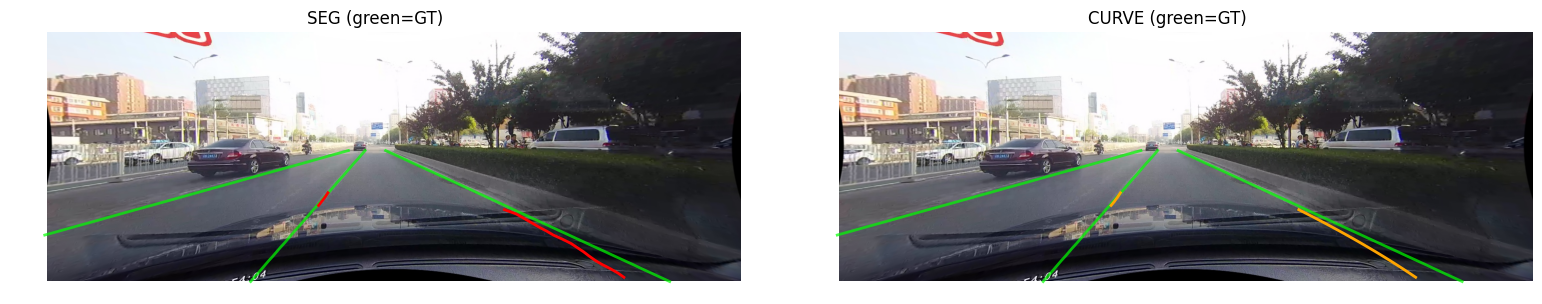

=== crowded ===


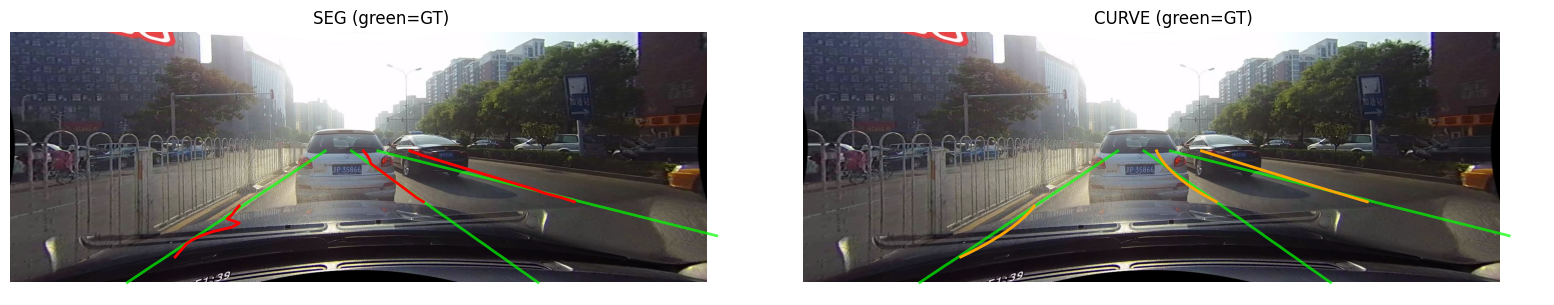

=== noline ===


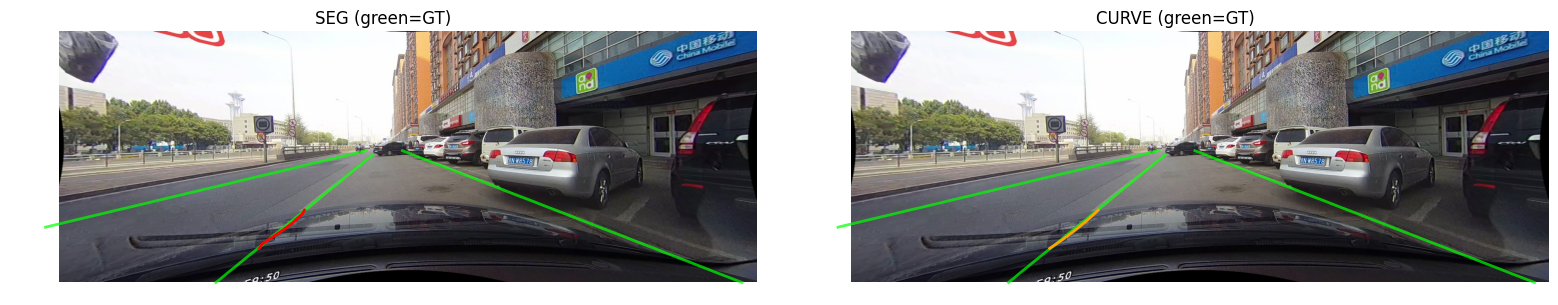

=== night ===


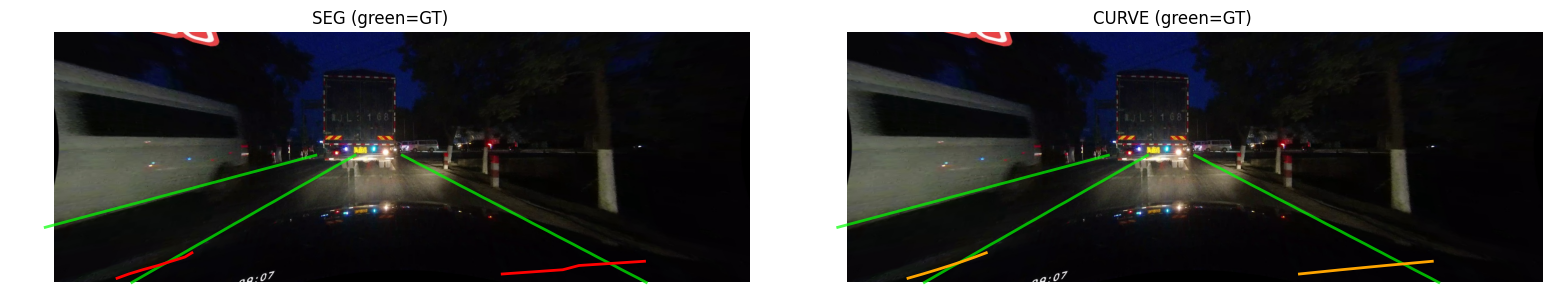

In [ ]:
import matplotlib.pyplot as plt, os, datetime
# results dir for THIS run (figures now; csvs + zip in the export cell)
_ts=datetime.datetime.now().strftime('%Y-%m-%d_%H%M')
RESULTS_DIR=f'/content/results/run_{_ts}'
FIG_DIR=os.path.join(RESULTS_DIR,'figures'); os.makedirs(FIG_DIR,exist_ok=True)
print('results dir:',RESULTS_DIR)

def draw(rel, save=None):
    img=cv2.cvtColor(cv2.imread(os.path.join(ROOT,rel)),cv2.COLOR_BGR2RGB)
    gt=cc.read_lines_txt(os.path.join(ROOT,rel.replace('.jpg','.lines.txt')))
    seg,cur=predictions(rel)
    def lay(ax,lanes,title,color):
        ax.imshow(img)
        for l in gt:
            ax.plot(l[:,0],l[:,1],color='lime',lw=2,alpha=.7)
        for l in lanes:
            ax.plot(l[:,0],l[:,1],color=color,lw=2)
        ax.set_title(title); ax.axis('off')
    fig,ax=plt.subplots(1,2,figsize=(16,3))
    lay(ax[0],seg,'SEG (green=GT)','red'); lay(ax[1],cur,'CURVE (green=GT)','orange')
    plt.tight_layout()
    if save: fig.savefig(save,dpi=110,bbox_inches='tight')
    plt.show()

for scen in cc.SCENARIO_FILES:
    fr=cc.load_scenario(ROOT,scen)
    if fr:
        print('===',scen,'==='); draw(fr[len(fr)//2], save=os.path.join(FIG_DIR,f'{scen}.png'))

## 11. Error-analysis summary (fill in after running)

Expected narrative to verify against your numbers:

- **F1 by scenario** should fall Normal → Crowded → Night → No-line for *both*
  methods; No-line is hardest (few/zero markings to segment).
- **SEG vs CURVE F1** are usually close (F1@IoU is gap-tolerant); the **lateral-distance**
  metric is where CURVE wins — polynomial smoothing reduces geometric error,
  most visibly on **Crowded** (occlusion gaps interpolated) and **Night** (noise smoothed).
- **Classical BEV** is near-zero everywhere → motivates the learned approach.

Write 1–2 paragraphs per scenario citing the table + the qualitative figures,
and note failure modes (e.g. curve over-extrapolation when only 2–3 points survive).

## 12. Export all results to a single zip on Drive

Saves the metric tables, training history, classical baseline, qualitative figures and a `summary.md` into `MyDrive/CULane/results/` and packs them into **one zip** (model NOT included). Download that single file and share it.

In [ ]:
# ====== EXPORT RESULTS -> single zip on Drive (model NOT included) ======
import os, shutil, datetime, pandas as pd

try:
    RESULTS_DIR
except NameError:                       # allow running this cell on its own
    _ts=datetime.datetime.now().strftime('%Y-%m-%d_%H%M')
    RESULTS_DIR=f'/content/results/run_{_ts}'
    os.makedirs(os.path.join(RESULTS_DIR,'figures'),exist_ok=True)

# 1. metric tables (Section 8) + comparison
for nm,var in [('metrics_seg.csv','seg_res'),('metrics_curve.csv','cur_res'),('comparison.csv','cmp')]:
    if var in globals():
        globals()[var].to_csv(os.path.join(RESULTS_DIR,nm)); print('saved',nm)

# 2. classical baseline (Section 9)
if 'per' in globals():
    pd.DataFrame({'classical_F1':per}).to_csv(os.path.join(RESULTS_DIR,'classical_baseline.csv'))
    print('saved classical_baseline.csv')

# 3. training history (Section 6)
if 'history' in globals():
    pd.DataFrame(history).to_csv(os.path.join(RESULTS_DIR,'training_history.csv'),index=False)
    print('saved training_history.csv')

# 4. human-readable summary
lines=['# Results summary',f'_generated {datetime.datetime.now():%Y-%m-%d %H:%M}_','']
if 'history' in globals() and history:
    lines+=['## Training (best val loss = %s)'%min(h["val_loss"] for h in history),
            '```',pd.DataFrame(history).to_string(index=False),'```','']
for ttl,var in [('SEGMENTATION (F1 + lateral px)','seg_res'),('CURVE (F1 + lateral px)','cur_res'),('SEG vs CURVE','cmp')]:
    if var in globals():
        lines+=['## '+ttl,'```',globals()[var].to_string(),'```','']
if 'per' in globals():
    lines+=['## Classical BEV baseline F1','```',str(per),'```','']
open(os.path.join(RESULTS_DIR,'summary.md'),'w').write('\n'.join(lines))
print('saved summary.md')

# 5. zip everything into Drive (single file)
DRIVE_OUT='/content/drive/MyDrive/CULane/results'; os.makedirs(DRIVE_OUT,exist_ok=True)
zpath=shutil.make_archive(os.path.join(DRIVE_OUT,os.path.basename(RESULTS_DIR)),'zip',RESULTS_DIR)
print('\nZIP READY ->',zpath)
print('Download this ONE file from Drive (MyDrive/CULane/results/) and upload it here.')

saved metrics_seg.csv
saved metrics_curve.csv
saved comparison.csv
saved classical_baseline.csv
saved training_history.csv
saved summary.md

ZIP READY -> /content/drive/MyDrive/CULane/results/run_2026-06-14_1231.zip
Download this ONE file from Drive (MyDrive/CULane/results/) and upload it here.
